In [49]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.nn.utils.rnn import pad_sequence, pack_padded_sequence, pad_packed_sequence
from sklearn.model_selection import train_test_split
from tqdm.auto import tqdm
import random
import os
import math

def seed_everything(seed):
    random.seed(seed)
    os.environ['PYTHONHASHSEED'] = str(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = True

SEED = 42
seed_everything(SEED)
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {DEVICE}")

# ======================================================
# [V12] Y축 데이터 증강 + MDN
# ======================================================
BATCH_SIZE = 64
LR_BASE = 1e-3
WARMUP_EPOCHS = 3
EPOCHS_BASE = 50
DROPOUT = 0.2
MAX_SEQ_LEN = 30
GRAD_CLIP = 1.0

HIDDEN_DIM = 256
LSTM_LAYERS = 3
BIDIRECTIONAL = True

# MDN 파라미터
NUM_GAUSSIANS = 2
MIN_SIGMA = 0.01
MAX_SIGMA = 0.3
HYBRID_LOSS_WEIGHT = 0.3

print(f"[V12] Y축 데이터 증강 + MDN")
print(f"  주요 기능:")
print(f"  1. ✅ Y축 반전 데이터 증강 (사이드라인 대칭성 활용)")
print(f"  2. MDN (2 Gaussians)")
print(f"  3. Spatial-Temporal Attention")
print(f"  4. Hybrid Loss (NLL + MSE)")

Device: cuda
[V12] Y축 데이터 증강 + MDN
  주요 기능:
  1. ✅ Y축 반전 데이터 증강 (사이드라인 대칭성 활용)
  2. MDN (2 Gaussians)
  3. Spatial-Temporal Attention
  4. Hybrid Loss (NLL + MSE)


In [50]:
# ======================================================
# 데이터 로드 (증강은 나중에!)
# ======================================================
BASE_DIR = "./open_track1"
if not os.path.exists(BASE_DIR): BASE_DIR = "."

TRAIN_PATH = os.path.join(BASE_DIR, "train.csv")
TEST_META_PATH = os.path.join(BASE_DIR, "test.csv")
MATCH_PATH = os.path.join(BASE_DIR, "match_info.csv")

train_df = pd.read_csv(TRAIN_PATH)
print(f"✅ Train Loaded: {train_df.shape}")

if os.path.exists(TEST_META_PATH):
    test_meta = pd.read_csv(TEST_META_PATH)
    print(f"ℹ️ Reading {len(test_meta)} test files...")
    test_dfs = []
    for _, row in tqdm(test_meta.iterrows(), total=len(test_meta), desc="Loading Test CSVs"):
        rel_path = row['path']
        paths_to_try = [
            rel_path,
            os.path.join(BASE_DIR, rel_path.lstrip("./")),
            os.path.join(BASE_DIR, "test", str(row['game_id']), os.path.basename(rel_path))
        ]
        for p in paths_to_try:
            if os.path.exists(p):
                test_dfs.append(pd.read_csv(p))
                break
    if test_dfs:
        test_df = pd.concat(test_dfs, ignore_index=True)
        print(f"✅ Test Data Merged: {test_df.shape}")
else:
    raise FileNotFoundError("test.csv not found")

if os.path.exists(MATCH_PATH):
    match_info = pd.read_csv(MATCH_PATH)
    match_subset = match_info[['game_id', 'home_team_id', 'venue']]
    train_df = pd.merge(train_df, match_subset, on='game_id', how='left')
    test_df = pd.merge(test_df, match_subset, on='game_id', how='left')

def preprocess(df):
    if 'home_team_id' in df.columns:
        df['is_home'] = (df['team_id'] == df['home_team_id']).astype(float)
    else:
        df['is_home'] = 0.5
    if 'end_x' not in df.columns:
        df['end_x'] = 0.0
        df['end_y'] = 0.0
    else:
        df['end_x'] = df['end_x'].fillna(0.0)
        df['end_y'] = df['end_y'].fillna(0.0)
    return df

train_df = preprocess(train_df)
test_df = preprocess(test_df)

ID_COL = 'game_episode' if 'game_episode' in train_df.columns else 'episode_id'
print(f"\nData Ready. ID Column: {ID_COL}")
print(f"⚠️ 데이터 증강은 train/val split 후에 적용됩니다 (데이터 유출 방지)")

✅ Train Loaded: (356721, 15)
ℹ️ Reading 2414 test files...


Loading Test CSVs: 100%|██████████| 2414/2414 [00:03<00:00, 684.90it/s]


✅ Test Data Merged: (53110, 15)

Data Ready. ID Column: game_episode
⚠️ 데이터 증강은 train/val split 후에 적용됩니다 (데이터 유출 방지)


In [51]:
# 피처 엔지니어링 (V11과 동일)
TOP_TYPES = ['Pass', 'Carry', 'Recovery', 'Interception', 'Duel', 'Tackle', 
             'Throw-In', 'Clearance', 'Intervention', 'Block', 'Pass_Freekick', 
             'Cross', 'Goal Kick', 'Error', 'Shot']
ALL_RESULTS = ['Successful', 'Unsuccessful', 'On Target', 'Yellow_Card', 
               'Blocked', 'Keeper Rush-Out', 'Low Quality Shot', 'Off Target']

def make_features(group):
    n = len(group)
    sx = group['start_x'].values / 105.0
    sy = group['start_y'].values / 68.0
    ex = group['end_x'].values / 105.0
    ey = group['end_y'].values / 68.0
    is_home = group['is_home'].values
    
    if 'time_seconds' in group.columns:
        times = group['time_seconds'].values
        dt = np.zeros(n, dtype=np.float32)
        dt[1:] = times[1:] - times[:-1]
        dt = np.maximum(dt, 0.1)
    else:
        dt = np.ones(n, dtype=np.float32)

    dx = ex - sx
    dy = ey - sy
    dist_meter = np.sqrt((dx*105)**2 + (dy*68)**2)
    cumsum_dx = np.cumsum(dx) / 105.0
    cumsum_dy = np.cumsum(dy) / 68.0
    lag_dist_m = np.roll(dist_meter, 1); lag_dist_m[0] = 0
    lag_cumsum_dx = np.roll(cumsum_dx, 1); lag_cumsum_dx[0] = 0
    lag_cumsum_dy = np.roll(cumsum_dy, 1); lag_cumsum_dy[0] = 0
    lag_dt = np.roll(dt, 1); lag_dt[0] = 1.0
    lag_speed = lag_dist_m / np.maximum(lag_dt, 0.1)
    
    if 'player_id' in group.columns:
        p_ids = group['player_id'].values
        is_same = np.zeros(n, dtype=np.float32)
        is_same[1:] = (p_ids[1:] == p_ids[:-1]).astype(np.float32)
    else:
        is_same = np.zeros(n, dtype=np.float32)

    progress = np.arange(n) / max(n-1, 1)
    is_second_half = (group['period_id'].values > 1).astype(np.float32) if 'period_id' in group.columns else np.zeros(n)
    
    GOAL_X, GOAL_Y = 105.0, 34.0
    sx_real, sy_real = sx * 105.0, sy * 68.0
    dist_to_goal = np.sqrt((sx_real - GOAL_X)**2 + (sy_real - GOAL_Y)**2) / 105.0
    angle_to_goal = np.arctan2(GOAL_Y - sy_real, GOAL_X - sx_real)
    angle_sin, angle_cos = np.sin(angle_to_goal), np.cos(angle_to_goal)
    dist_to_sideline = np.minimum(sy_real, 68.0 - sy_real) / 68.0
    dist_to_endline = np.minimum(sx_real, 105.0 - sx_real) / 105.0
    
    def get_zone(x_norm):
        if x_norm < 35.0/105.0: return 0
        elif x_norm < 70.0/105.0: return 1
        else: return 2
    
    zones = np.array([get_zone(x) for x in sx])
    zone_onehot = np.zeros((n, 3), dtype=np.float32)
    for i, z in enumerate(zones): zone_onehot[i, z] = 1.0
    
    types_onehot = np.zeros((n, len(TOP_TYPES) + 1), dtype=np.float32)
    for i, t in enumerate(group['type_name'].values):
        types_onehot[i, TOP_TYPES.index(t) if t in TOP_TYPES else -1] = 1.0
    
    results_onehot = np.zeros((n, len(ALL_RESULTS) + 1), dtype=np.float32)
    for i, r in enumerate(group['result_name'].values):
        results_onehot[i, ALL_RESULTS.index(r) if r in ALL_RESULTS else -1] = 1.0

    features = []
    for i in range(n):
        scalars = [sx[i], sy[i], lag_cumsum_dx[i], lag_cumsum_dy[i], lag_dist_m[i]/100.0,
                   lag_speed[i]/10.0, dt[i]/10.0, progress[i], is_home[i], is_same[i],
                   is_second_half[i], dist_to_goal[i], angle_sin[i], angle_cos[i],
                   dist_to_sideline[i], dist_to_endline[i]]
        feat_vec = np.concatenate([scalars, zone_onehot[i], types_onehot[i], results_onehot[i]])
        features.append(feat_vec)
        
        if i < n - 1:
            ex_real, ey_real = ex[i] * 105.0, ey[i] * 68.0
            end_dist_to_goal = np.sqrt((ex_real - GOAL_X)**2 + (ey_real - GOAL_Y)**2) / 105.0
            end_angle = np.arctan2(GOAL_Y - ey_real, GOAL_X - ex_real)
            scalars_end = scalars.copy()
            scalars_end[0:2] = [ex[i], ey[i]]
            scalars_end[2:4] = [cumsum_dx[i], cumsum_dy[i]]
            scalars_end[11:16] = [end_dist_to_goal, np.sin(end_angle), np.cos(end_angle),
                                   min(ey_real, 68.0 - ey_real) / 68.0,
                                   min(ex_real, 105.0 - ex_real) / 105.0]
            end_zone_onehot = np.zeros(3, dtype=np.float32)
            end_zone_onehot[get_zone(ex[i])] = 1.0
            feat_vec_end = np.concatenate([scalars_end, end_zone_onehot, types_onehot[i], results_onehot[i]])
            features.append(feat_vec_end)
            
    return np.array(features, dtype=np.float32)

dummy_group = train_df.iloc[:5].copy()
INPUT_DIM = make_features(dummy_group).shape[1]
print(f"✅ Input Dimension: {INPUT_DIM}")

✅ Input Dimension: 44


In [52]:
# 데이터셋 (증강 없이 원본만)
class SoccerDataset(Dataset):
    def __init__(self, df, mode='train', augment_y=False):
        """
        augment_y: Y축 반전 증강 여부 (train/val split 후 train만 적용)
        """
        self.mode = mode
        self.augment_y = augment_y
        self.episodes, self.targets, self.team_ids, self.episode_ids = [], [], [], []
        
        for name, group in tqdm(df.groupby(ID_COL, sort=False), desc=f"Dataset ({mode})"):
            if mode == 'train' and len(group) < 2: continue
            
            # 원본 추가
            seq = make_features(group)
            team_id = group.iloc[0]['team_id']
            if mode == 'train':
                last = group.iloc[-1]
                self.targets.append([last['end_x']/105.0, last['end_y']/68.0])
                self.episodes.append(seq)
                self.team_ids.append(team_id)
            else:
                self.episodes.append(seq)
                self.team_ids.append(team_id)
                self.episode_ids.append(str(name))
            
            # 🆕 Y축 증강 (train만!)
            if mode == 'train' and augment_y:
                group_aug = group.copy()
                group_aug['start_y'] = 68.0 - group_aug['start_y']
                group_aug['end_y'] = 68.0 - group_aug['end_y']
                
                seq_aug = make_features(group_aug)
                last_aug = group_aug.iloc[-1]
                self.targets.append([last_aug['end_x']/105.0, last_aug['end_y']/68.0])
                self.episodes.append(seq_aug)
                self.team_ids.append(team_id)

    def __len__(self): return len(self.episodes)
    def __getitem__(self, idx):
        seq = torch.FloatTensor(self.episodes[idx])
        if len(seq) > MAX_SEQ_LEN: seq = seq[-MAX_SEQ_LEN:]
        if self.mode == 'train':
            return seq, torch.FloatTensor(self.targets[idx]), self.team_ids[idx]
        return seq, self.team_ids[idx], self.episode_ids[idx]

def collate_fn(batch):
    seqs = [b[0] for b in batch]
    lens = torch.LongTensor([len(s) for s in seqs])
    padded = pad_sequence(seqs, batch_first=True, padding_value=0)
    mask = torch.arange(padded.size(1))[None, :] >= lens[:, None]
    if isinstance(batch[0][2], str):
        return padded, mask, lens, torch.LongTensor([b[1] for b in batch]), [b[2] for b in batch]
    return padded, torch.stack([b[1] for b in batch]), mask, lens, torch.LongTensor([b[2] for b in batch])

# 🆕 원본만으로 데이터셋 생성 (증강은 학습 때!)
full_dataset = SoccerDataset(train_df, mode='train', augment_y=False)
test_dataset = SoccerDataset(test_df, mode='test', augment_y=False)
print(f"✅ Dataset: {len(full_dataset)} episodes (증강 전)")
print(f"✅ Test: {len(test_dataset)} episodes")

Dataset (test): 100%|██████████| 2414/2414 [00:02<00:00, 1046.38it/s]

✅ Dataset: 15428 episodes (증강 전)
✅ Test: 2414 episodes


In [53]:
# ======================================================
# [V12] Y축 증강 + MDN 모델 + Smart 예측 전략
# ======================================================

class SpatialAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.goal_attn = nn.Sequential(nn.Linear(3, 16), nn.ReLU(), nn.Linear(16, 1))
        self.zone_attn = nn.Sequential(nn.Linear(3, 8), nn.ReLU(), nn.Linear(8, 1))
        self.pos_attn = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1))
        self.fusion = nn.Linear(3, 1)
    def forward(self, x):
        return self.fusion(torch.cat([self.pos_attn(x[..., 0:2]), 
                                       self.goal_attn(x[..., 11:14]), 
                                       self.zone_attn(x[..., 16:19])], dim=-1))

class TemporalAttention(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.pos_encoding = nn.Parameter(torch.randn(1, 100, hidden_dim) * 0.02)
        self.temporal_attn = nn.Sequential(nn.Linear(hidden_dim, hidden_dim // 2), 
                                           nn.Tanh(), nn.Dropout(0.1), 
                                           nn.Linear(hidden_dim // 2, 1))
    def forward(self, lstm_out):
        return self.temporal_attn(lstm_out + self.pos_encoding[:, :lstm_out.size(1), :])

class SpatialTemporalFusion(nn.Module):
    def __init__(self, hidden_dim):
        super().__init__()
        self.spatial_weight = nn.Parameter(torch.tensor(0.5))
        self.temporal_weight = nn.Parameter(torch.tensor(0.5))
        self.combine = nn.Sequential(nn.Linear(2, 8), nn.ReLU(), nn.Linear(8, 1), nn.Sigmoid())
    def forward(self, s, t):
        return (torch.sigmoid(self.spatial_weight) * s + 
                torch.sigmoid(self.temporal_weight) * t) * self.combine(torch.cat([s, t], -1))

class ImprovedMDNPredictor(nn.Module):
    """
    [V12] Y축 증강 + MDN
    - Gaussian 수 감소 (2개)
    - Sigma 범위 제한
    - 초기화 개선
    """
    def __init__(self, input_dim, hidden_dim, num_layers, dropout, num_gaussians=2, bidirectional=True):
        super().__init__()
        self.num_gaussians = num_gaussians
        
        self.lstm = nn.LSTM(input_dim, hidden_dim, num_layers, batch_first=True,
                           dropout=dropout if num_layers > 1 else 0, bidirectional=bidirectional)
        lstm_output_dim = hidden_dim * 2 if bidirectional else hidden_dim
        
        self.spatial_attn = SpatialAttention(lstm_output_dim)
        self.temporal_attn = TemporalAttention(lstm_output_dim)
        self.fusion = SpatialTemporalFusion(lstm_output_dim)
        
        # MDN Heads (더 강력한 초기화)
        self.pi_head = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim // 2, num_gaussians)
        )
        self.mu_head = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim // 2, num_gaussians * 2)
        )
        self.sigma_head = nn.Sequential(
            nn.Linear(lstm_output_dim, lstm_output_dim // 2),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(lstm_output_dim // 2, num_gaussians * 2)
        )
        
        # ✅ Mu 초기화: 중앙 근처 bias
        nn.init.constant_(self.mu_head[-1].bias, 0.5)
        nn.init.xavier_uniform_(self.mu_head[-1].weight, gain=0.1)

    def forward(self, x, mask=None, lengths=None):
        batch_size, seq_len = x.size(0), x.size(1)
        
        # LSTM + Attention
        if lengths is not None:
            packed = pack_padded_sequence(x, lengths.cpu(), batch_first=True, enforce_sorted=False)
            lstm_out, _ = self.lstm(packed)
            lstm_out, _ = pad_packed_sequence(lstm_out, batch_first=True, total_length=seq_len)
        else:
            lstm_out, _ = self.lstm(x)
        
        fused_attn = self.fusion(self.spatial_attn(x), self.temporal_attn(lstm_out))
        if mask is not None:
            fused_attn = fused_attn.masked_fill(mask.unsqueeze(-1), float('-inf'))
        final_attn = torch.softmax(fused_attn, dim=1)
        context = torch.sum(lstm_out * final_attn, dim=1)
        
        # MDN 출력
        pi = torch.softmax(self.pi_head(context), dim=1)
        mu = torch.sigmoid(self.mu_head(context)).view(batch_size, self.num_gaussians, 2)  # ✅ Sigmoid로 0~1 강제
        
        # ✅ Sigma 범위 제한: [MIN_SIGMA, MAX_SIGMA]
        sigma_raw = self.sigma_head(context).view(batch_size, self.num_gaussians, 2)
        sigma = torch.sigmoid(sigma_raw) * (MAX_SIGMA - MIN_SIGMA) + MIN_SIGMA
        
        return pi, mu, sigma


def hybrid_mdn_loss(pi, mu, sigma, target, mse_weight=HYBRID_LOSS_WEIGHT):
    """
    ✅ Hybrid Loss: NLL + MSE
    - NLL: 확률 분포 학습
    - MSE: 직접적인 좌표 학습 (안정성)
    """
    batch_size = target.size(0)
    target_expanded = target.unsqueeze(1).expand_as(mu)
    
    # NLL Loss
    diff = target_expanded - mu
    log_prob_components = (
        -0.5 * math.log(2 * math.pi) - torch.log(sigma) - 0.5 * (diff / sigma) ** 2
    )
    log_prob = log_prob_components.sum(dim=2)
    weighted_log_prob = log_prob + torch.log(pi + 1e-8)
    nll_loss = -torch.logsumexp(weighted_log_prob, dim=1).mean()
    
    # ✅ MSE Loss (가중 평균 예측)
    pred_mean = (pi.unsqueeze(-1) * mu).sum(dim=1)
    mse_loss = nn.functional.mse_loss(pred_mean, target)
    
    # Hybrid
    total_loss = nll_loss + mse_weight * mse_loss
    
    return total_loss, nll_loss, mse_loss


def mdn_predict_improved(pi, mu, sigma, strategy='mean', entropy_threshold=0.5):
    """
    ✅ MDN 예측 전략 (리서치 기반 - 2025)
    
    전략:
    - mode: 가장 높은 확률의 Gaussian 선택 (과감한 선택)
    - mean: 모든 Gaussian의 가중평균 (안정적인 선택)
    - smart: ✨ Entropy 기반 하이브리드 (논문/실무에서 권장) ✨
      → Entropy = -Σ(pi * log(pi))
      → 낮은 entropy (< threshold): 확신도 높음 → mode 사용 (확실할 땐 과감하게)
      → 높은 entropy (≥ threshold): 불확실 → mean 사용 (애매할 땐 안전하게)
    
    Args:
        pi: Mixing coefficients [batch, num_gaussians]
        mu: Means [batch, num_gaussians, 2]
        sigma: Std devs [batch, num_gaussians, 2]
        strategy: 'mode', 'mean', 'smart'
        entropy_threshold: Smart 전략에서 mode/mean 전환 임계값
                          2개 Gaussian 기준: max_entropy = -2*(0.5*log(0.5)) ≈ 0.693
                          기본값 0.5는 균일분포의 ~72%
    
    Returns:
        pred: [batch, 2] (normalized 0~1)
    
    참고:
    - Basketball Trajectory Prediction (2017): 농구 궤적 예측에서 MDN 사용
    - Quantum MDN (2025): 최신 MDN 연구
    - Law of Total Variance: Entropy로 불확실성 측정
    """
    if strategy == 'mode':
        # 가장 확률이 높은 Gaussian 선택
        max_idx = torch.argmax(pi, dim=1)
        pred = mu[torch.arange(len(mu)), max_idx]
    
    elif strategy == 'mean':
        # 가중평균 (모든 옵션 고려) - 현재 가장 안정적
        pred = (pi.unsqueeze(-1) * mu).sum(dim=1)
    
    elif strategy == 'smart':
        # ✨ Entropy 기반 적응형 전략 (리서치 결과 반영)
        # Entropy 계산: H = -Σ(pi * log(pi))
        entropy = -(pi * torch.log(pi + 1e-8)).sum(dim=1)  # [batch]
        
        # 확신도 기반 예측
        pred = torch.zeros_like(mu[:, 0])  # [batch, 2]
        
        # 낮은 entropy (확신) → mode 사용
        confident_mask = entropy < entropy_threshold
        if confident_mask.sum() > 0:
            max_idx = torch.argmax(pi[confident_mask], dim=1)
            pred[confident_mask] = mu[confident_mask][torch.arange(confident_mask.sum()), max_idx]
        
        # 높은 entropy (불확실) → mean 사용
        uncertain_mask = ~confident_mask
        if uncertain_mask.sum() > 0:
            pred[uncertain_mask] = (pi[uncertain_mask].unsqueeze(-1) * mu[uncertain_mask]).sum(dim=1)
    
    else:
        raise ValueError(f"Unknown strategy: {strategy}. Use 'mode', 'mean', or 'smart'.")
    
    return torch.clamp(pred, 0.0, 1.0)


model = ImprovedMDNPredictor(INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, NUM_GAUSSIANS, BIDIRECTIONAL).to(DEVICE)

print("="*70)
print("✅ [V12] Y축 증강 + MDN 모델 준비 완료 (Smart 전략 추가)")
print("="*70)
print(f"주요 개선사항:")
print(f"  1. ✅ Y축 데이터 증강 (훈련 데이터 2배)")
print(f"  2. Gaussians: 2개 (단순화)")
print(f"  3. Mu: Sigmoid로 0~1 보장")
print(f"  4. Sigma: [{MIN_SIGMA}, {MAX_SIGMA}] 제한")
print(f"  5. Loss: Hybrid (NLL + {HYBRID_LOSS_WEIGHT}*MSE)")
print(f"  6. 예측 전략: mode / mean / ✨smart (Entropy 기반)")
print(f"  7. LR: {LR_BASE}")
print(f"  Parameters: {sum(p.numel() for p in model.parameters()):,}")
print("="*70)
print(f"\n📚 Smart 전략 설명:")
print(f"  - Entropy < threshold → Mode (확실할 때 과감하게)")
print(f"  - Entropy ≥ threshold → Mean (애매할 때 안전하게)")
print(f"  - 기본 threshold: 0.5 (2 Gaussians, max=0.693)")
print("="*70)

✅ [V12] Y축 증강 + MDN 모델 준비 완료 (Smart 전략 추가)
주요 개선사항:
  1. ✅ Y축 데이터 증강 (훈련 데이터 2배)
  2. Gaussians: 2개 (단순화)
  3. Mu: Sigmoid로 0~1 보장
  4. Sigma: [0.01, 0.3] 제한
  5. Loss: Hybrid (NLL + 0.3*MSE)
  6. 예측 전략: mode / mean / ✨smart (Entropy 기반)
  7. LR: 0.001
  Parameters: 4,351,949

📚 Smart 전략 설명:
  - Entropy < threshold → Mode (확실할 때 과감하게)
  - Entropy ≥ threshold → Mean (애매할 때 안전하게)
  - 기본 threshold: 0.5 (2 Gaussians, max=0.693)


In [54]:
# ======================================================
# [V12] Y축 증강 학습 (데이터 유출 방지!)
# ======================================================
from torch.optim.lr_scheduler import CosineAnnealingLR

SEEDS = [42, 2024, 777]
PRED_STRATEGY = 'smart'  # ✨ 'mode', 'mean', 'smart' 중 선택
ENTROPY_THRESHOLD = 0.4   # ✨ Smart 전략 threshold (기본: 0.5, 실험: 0.4)
USE_Y_AUGMENTATION = True  # Y축 증강 사용

print(f"\n{'='*70}")
print(f"🚀 [V12] Y축 증강 + MDN 학습 시작")
print(f"{'='*70}")
print(f"✅ 데이터 유출 방지: train/val split 후 train만 증강")
print(f"✨ 예측 전략: {PRED_STRATEGY}")
if PRED_STRATEGY == 'smart':
    print(f"✨ Entropy Threshold: {ENTROPY_THRESHOLD}")
print(f"{'='*70}\n")

all_histories = []

for i, seed in enumerate(SEEDS):
    print(f"\n{'='*70}")
    print(f"📦 [모델 {i+1}/3] Seed {seed}")
    print(f"{'='*70}")
    seed_everything(seed)
    
    # 1. 먼저 train/val split (원본 데이터로)
    train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=seed)
    
    # 2. train 부분만 Y축 증강 적용
    train_subset_df = train_df[train_df[ID_COL].isin(train_df.groupby(ID_COL).head(1).iloc[train_idx][ID_COL].values)]
    val_subset_df = train_df[train_df[ID_COL].isin(train_df.groupby(ID_COL).head(1).iloc[val_idx][ID_COL].values)]
    
    # 3. 증강된 데이터셋 생성
    train_dataset_aug = SoccerDataset(train_subset_df, mode='train', augment_y=USE_Y_AUGMENTATION)
    val_dataset = SoccerDataset(val_subset_df, mode='train', augment_y=False)  # validation은 증강 X
    
    print(f"  Train: {len(train_dataset_aug)} episodes ({'증강 2배' if USE_Y_AUGMENTATION else '원본'})")
    print(f"  Val: {len(val_dataset)} episodes (원본만)")
    
    train_loader = DataLoader(train_dataset_aug, batch_size=BATCH_SIZE, shuffle=True, collate_fn=collate_fn)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)
    
    model = ImprovedMDNPredictor(INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, 
                                 NUM_GAUSSIANS, BIDIRECTIONAL).to(DEVICE)
    optimizer = optim.AdamW(model.parameters(), lr=LR_BASE, weight_decay=1e-4)
    scheduler = CosineAnnealingLR(optimizer, T_max=EPOCHS_BASE - WARMUP_EPOCHS, eta_min=1e-6)
    
    best_dist = float('inf')
    history = {'train_loss': [], 'train_nll': [], 'train_mse': [], 'val_dist': [], 'lr': []}
    
    for epoch in range(EPOCHS_BASE):
        # Warmup
        if epoch < WARMUP_EPOCHS:
            for param_group in optimizer.param_groups:
                param_group['lr'] = LR_BASE * (epoch + 1) / WARMUP_EPOCHS
        
        # Training
        model.train()
        train_loss, train_nll, train_mse = 0.0, 0.0, 0.0
        for seqs, targets, mask, lens, _ in train_loader:
            seqs, targets, mask, lens = seqs.to(DEVICE), targets.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
            optimizer.zero_grad()
            pi, mu, sigma = model(seqs, mask, lens)
            loss, nll, mse = hybrid_mdn_loss(pi, mu, sigma, targets)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            optimizer.step()
            train_loss += loss.item()
            train_nll += nll.item()
            train_mse += mse.item()
        
        # Validation
        model.eval()
        dists = []
        with torch.no_grad():
            for seqs, targets, mask, lens, _ in val_loader:
                seqs, targets, mask, lens = seqs.to(DEVICE), targets.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
                pi, mu, sigma = model(seqs, mask, lens)
                # ✨ Smart 전략 적용
                pred = mdn_predict_improved(pi, mu, sigma, strategy=PRED_STRATEGY, entropy_threshold=ENTROPY_THRESHOLD)
                p_real = pred.cpu().numpy() * np.array([105.0, 68.0])
                t_real = targets.cpu().numpy() * np.array([105.0, 68.0])
                dists.extend(np.sqrt(np.sum((p_real - t_real)**2, axis=1)))
        
        avg_dist = np.mean(dists)
        avg_loss = train_loss / len(train_loader)
        avg_nll = train_nll / len(train_loader)
        avg_mse = train_mse / len(train_loader)
        
        if epoch >= WARMUP_EPOCHS:
            scheduler.step()
        
        current_lr = optimizer.param_groups[0]['lr']
        history['train_loss'].append(avg_loss)
        history['train_nll'].append(avg_nll)
        history['train_mse'].append(avg_mse)
        history['val_dist'].append(avg_dist)
        history['lr'].append(current_lr)
        
        if (epoch + 1) % 5 == 0 or epoch < 5:
            print(f"  [Epoch {epoch+1:2d}/{EPOCHS_BASE}] "
                  f"Loss: {avg_loss:.4f} (NLL: {avg_nll:.4f}, MSE: {avg_mse:.4f}) | "
                  f"Val: {avg_dist:.4f}m | LR: {current_lr:.6f}")
        
        if avg_dist < best_dist:
            best_dist = avg_dist
            torch.save(model.state_dict(), f'v12_y_aug_mdn_{i}.pth')
    
    history['best_dist'] = best_dist
    history['seed'] = seed
    all_histories.append(history)
    print(f"  ✅ Best: {best_dist:.4f}m")

print(f"\n{'='*70}")
print(f"✅ 학습 완료!")
print(f"{'='*70}")
print(f"평균 Best: {np.mean([h['best_dist'] for h in all_histories]):.4f}m")
print(f"최고 성능: {min([h['best_dist'] for h in all_histories]):.4f}m")
print(f"{'='*70}")


🚀 [V12] Y축 증강 + MDN 학습 시작
✅ 데이터 유출 방지: train/val split 후 train만 증강
✨ 예측 전략: smart
✨ Entropy Threshold: 0.4


📦 [모델 1/3] Seed 42


Dataset (train): 100%|██████████| 3086/3086 [00:03<00:00, 861.53it/s]


  Train: 24672 episodes (증강 2배)
  Val: 3085 episodes (원본만)
  [Epoch  1/50] Loss: 0.2590 (NLL: 0.2322, MSE: 0.0895) | Val: 27.9857m | LR: 0.000333
  [Epoch  2/50] Loss: -0.6953 (NLL: -0.7111, MSE: 0.0525) | Val: 16.4416m | LR: 0.000667
  [Epoch  3/50] Loss: -1.1289 (NLL: -1.1382, MSE: 0.0310) | Val: 15.7579m | LR: 0.001000
  [Epoch  4/50] Loss: -1.2598 (NLL: -1.2684, MSE: 0.0287) | Val: 15.6945m | LR: 0.000999
  [Epoch  5/50] Loss: -1.3404 (NLL: -1.3487, MSE: 0.0277) | Val: 15.0659m | LR: 0.000996
  [Epoch 10/50] Loss: -1.5619 (NLL: -1.5696, MSE: 0.0257) | Val: 14.4656m | LR: 0.000946
  [Epoch 15/50] Loss: -1.7062 (NLL: -1.7136, MSE: 0.0247) | Val: 14.0532m | LR: 0.000848
  [Epoch 20/50] Loss: -1.8568 (NLL: -1.8639, MSE: 0.0237) | Val: 14.2712m | LR: 0.000711
  [Epoch 25/50] Loss: -2.0391 (NLL: -2.0457, MSE: 0.0220) | Val: 14.2549m | LR: 0.000550
  [Epoch 30/50] Loss: -2.2472 (NLL: -2.2532, MSE: 0.0200) | Val: 14.1483m | LR: 0.000385
  [Epoch 35/50] Loss: -2.4478 (NLL: -2.4533, MSE: 0.0

Dataset (train): 100%|██████████| 3086/3086 [00:04<00:00, 762.73it/s]


  Train: 24670 episodes (증강 2배)
  Val: 3086 episodes (원본만)
  [Epoch  1/50] Loss: 0.1139 (NLL: 0.0926, MSE: 0.0710) | Val: 18.6227m | LR: 0.000333
  [Epoch  2/50] Loss: -0.9873 (NLL: -0.9974, MSE: 0.0337) | Val: 16.8389m | LR: 0.000667
  [Epoch  3/50] Loss: -1.1491 (NLL: -1.1585, MSE: 0.0312) | Val: 16.4324m | LR: 0.001000
  [Epoch  4/50] Loss: -1.2573 (NLL: -1.2661, MSE: 0.0294) | Val: 15.3531m | LR: 0.000999
  [Epoch  5/50] Loss: -1.3256 (NLL: -1.3341, MSE: 0.0283) | Val: 15.4566m | LR: 0.000996
  [Epoch 10/50] Loss: -1.5603 (NLL: -1.5682, MSE: 0.0261) | Val: 14.3571m | LR: 0.000946
  [Epoch 15/50] Loss: -1.7294 (NLL: -1.7370, MSE: 0.0252) | Val: 14.2333m | LR: 0.000848
  [Epoch 20/50] Loss: -1.8581 (NLL: -1.8653, MSE: 0.0240) | Val: 14.0949m | LR: 0.000711
  [Epoch 25/50] Loss: -1.9831 (NLL: -1.9900, MSE: 0.0230) | Val: 13.8716m | LR: 0.000550
  [Epoch 30/50] Loss: -2.1260 (NLL: -2.1325, MSE: 0.0216) | Val: 13.9362m | LR: 0.000385
  [Epoch 35/50] Loss: -2.3027 (NLL: -2.3087, MSE: 0.0

Dataset (train): 100%|██████████| 3086/3086 [00:03<00:00, 882.22it/s] 


  Train: 24674 episodes (증강 2배)
  Val: 3084 episodes (원본만)
  [Epoch  1/50] Loss: 0.2127 (NLL: 0.1899, MSE: 0.0758) | Val: 24.2316m | LR: 0.000333
  [Epoch  2/50] Loss: -0.8604 (NLL: -0.8716, MSE: 0.0373) | Val: 16.0467m | LR: 0.000667
  [Epoch  3/50] Loss: -1.1276 (NLL: -1.1371, MSE: 0.0317) | Val: 16.0079m | LR: 0.001000
  [Epoch  4/50] Loss: -1.2393 (NLL: -1.2484, MSE: 0.0301) | Val: 15.5887m | LR: 0.000999
  [Epoch  5/50] Loss: -1.2992 (NLL: -1.3079, MSE: 0.0290) | Val: 15.1161m | LR: 0.000996
  [Epoch 10/50] Loss: -1.5934 (NLL: -1.6012, MSE: 0.0261) | Val: 14.3264m | LR: 0.000946
  [Epoch 15/50] Loss: -1.7538 (NLL: -1.7612, MSE: 0.0246) | Val: 14.1232m | LR: 0.000848
  [Epoch 20/50] Loss: -1.8792 (NLL: -1.8862, MSE: 0.0235) | Val: 13.9083m | LR: 0.000711
  [Epoch 25/50] Loss: -2.0396 (NLL: -2.0462, MSE: 0.0220) | Val: 14.1082m | LR: 0.000550
  [Epoch 30/50] Loss: -2.2189 (NLL: -2.2250, MSE: 0.0203) | Val: 14.1595m | LR: 0.000385
  [Epoch 35/50] Loss: -2.4256 (NLL: -2.4311, MSE: 0.0

In [55]:
# 추론
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

models = []
for i in range(3):
    model = ImprovedMDNPredictor(INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, 
                                 NUM_GAUSSIANS, BIDIRECTIONAL).to(DEVICE)
    model.load_state_dict(torch.load(f'v12_y_aug_mdn_{i}.pth'))
    model.eval()
    models.append(model)

results = []
with torch.no_grad():
    for seqs, mask, lens, team_ids, episode_ids in tqdm(test_loader, desc="Inference"):
        seqs, mask, lens = seqs.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
        preds = []
        for model in models:
            pi, mu, sigma = model(seqs, mask, lens)
            # ✨ Smart 전략 적용
            pred = mdn_predict_improved(pi, mu, sigma, strategy=PRED_STRATEGY, entropy_threshold=ENTROPY_THRESHOLD)
            preds.append(pred.cpu().numpy())
        avg_pred = np.mean(preds, axis=0)
        for i, eid in enumerate(episode_ids):
            results.append({'game_episode': eid, 'pred_x': avg_pred[i, 0] * 105.0, 
                          'pred_y': avg_pred[i, 1] * 68.0})

pred_df = pd.DataFrame(results)
SUBMISSION_PATH = "open_track1/sample_submission.csv"
if os.path.exists(SUBMISSION_PATH):
    sub = pd.read_csv(SUBMISSION_PATH)
else:
    sub = pd.read_csv(TEST_META_PATH).rename(columns={'episode_id': 'game_episode'})[['game_episode']]

final_sub = pd.merge(sub[['game_episode']], pred_df, on='game_episode', how='left')
final_sub = final_sub.rename(columns={'pred_x': 'end_x', 'pred_y': 'end_y'})
if final_sub.isnull().sum().sum() > 0:
    final_sub = final_sub.fillna(50.0)

filename = f"v12_y_aug_mdn_{PRED_STRATEGY}_submit.csv"
final_sub.to_csv(filename, index=False)

print(f"\n✅ 제출 파일: {filename}")
print(f"📊 적용된 기법:")
print(f"  - Y축 데이터 증강 (훈련 데이터 2배)")
print(f"  - 3-Seed 앙상블")
print(f"  - MDN (2 Gaussians)")
print(f"  - Spatial-Temporal Attention")
print(f"  - ✨ 예측 전략: {PRED_STRATEGY}" + (f" (threshold={ENTROPY_THRESHOLD})" if PRED_STRATEGY == 'smart' else ""))
print(final_sub.head())

Inference: 100%|██████████| 38/38 [00:01<00:00, 32.67it/s]


✅ 제출 파일: v12_y_aug_mdn_smart_submit.csv
📊 적용된 기법:
  - Y축 데이터 증강 (훈련 데이터 2배)
  - 3-Seed 앙상블
  - MDN (2 Gaussians)
  - Spatial-Temporal Attention
  - ✨ 예측 전략: smart (threshold=0.4)
  game_episode      end_x      end_y
0     153363_1  64.694945  12.164698
1     153363_2  44.942842  56.358239
2     153363_6  37.648825  62.893119
3     153363_7  67.049701   9.322366
4     153363_8  81.194916   8.441089


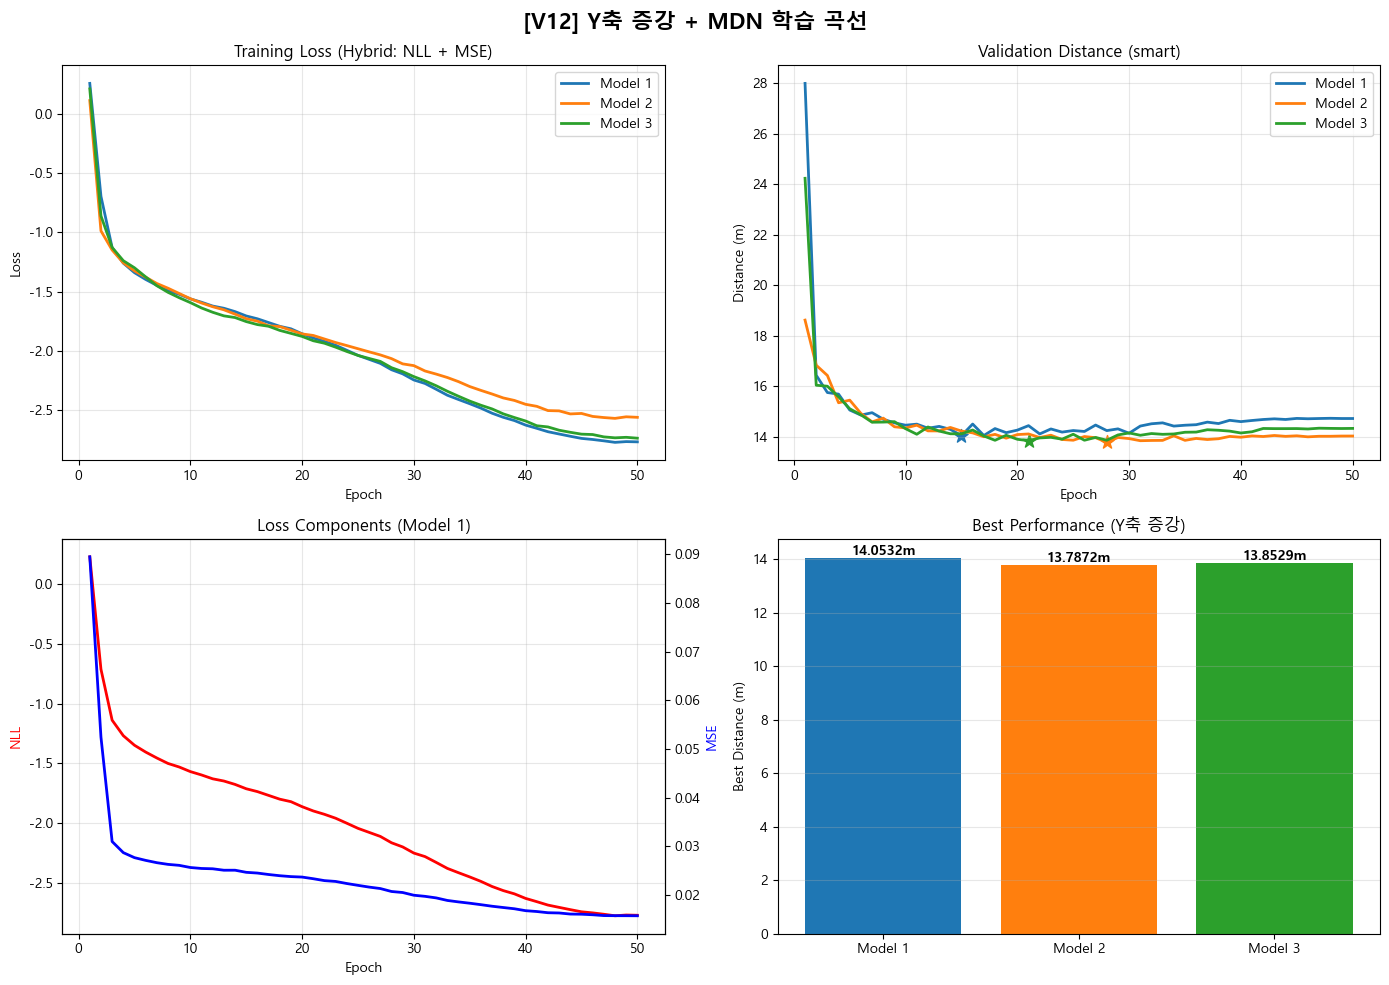


최종 결과:
  Model 1: 14.0532m
  Model 2: 13.7872m
  Model 3: 13.8529m
  평균: 13.8977m


In [56]:
# 시각화
import matplotlib.pyplot as plt
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('[V12] Y축 증강 + MDN 학습 곡선', fontsize=16, fontweight='bold')

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

# 1. Hybrid Loss
ax1 = axes[0, 0]
for i, h in enumerate(all_histories):
    epochs = range(1, len(h['train_loss']) + 1)
    ax1.plot(epochs, h['train_loss'], label=f"Model {i+1}", color=colors[i], linewidth=2)
ax1.set_title('Training Loss (Hybrid: NLL + MSE)')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Validation Distance
ax2 = axes[0, 1]
for i, h in enumerate(all_histories):
    epochs = range(1, len(h['val_dist']) + 1)
    ax2.plot(epochs, h['val_dist'], label=f"Model {i+1}", color=colors[i], linewidth=2)
    best_idx = np.argmin(h['val_dist'])
    ax2.scatter(best_idx + 1, h['val_dist'][best_idx], color=colors[i], s=100, marker='*')
ax2.set_title(f'Validation Distance ({PRED_STRATEGY})')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Distance (m)')
ax2.legend()
ax2.grid(True, alpha=0.3)

# 3. NLL vs MSE
ax3 = axes[1, 0]
h = all_histories[0]
epochs = range(1, len(h['train_nll']) + 1)
ax3.plot(epochs, h['train_nll'], label='NLL', color='red', linewidth=2)
ax3_twin = ax3.twinx()
ax3_twin.plot(epochs, h['train_mse'], label='MSE', color='blue', linewidth=2)
ax3.set_xlabel('Epoch')
ax3.set_ylabel('NLL', color='red')
ax3_twin.set_ylabel('MSE', color='blue')
ax3.set_title('Loss Components (Model 1)')
ax3.grid(True, alpha=0.3)

# 4. Best Distances
ax4 = axes[1, 1]
best_dists = [h['best_dist'] for h in all_histories]
bars = ax4.bar(range(len(best_dists)), best_dists, color=colors)
ax4.set_xticks(range(len(best_dists)))
ax4.set_xticklabels([f'Model {i+1}' for i in range(len(best_dists))])
ax4.set_ylabel('Best Distance (m)')
ax4.set_title('Best Performance (Y축 증강)')
for bar, dist in zip(bars, best_dists):
    ax4.text(bar.get_x() + bar.get_width()/2., bar.get_height(), 
             f'{dist:.4f}m', ha='center', va='bottom', fontweight='bold')
ax4.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('v12_y_aug_mdn_history.png', dpi=150)
plt.show()

print(f"\n최종 결과:")
for i, h in enumerate(all_histories):
    print(f"  Model {i+1}: {h['best_dist']:.4f}m")
print(f"  평균: {np.mean(best_dists):.4f}m")

🔍 Entropy 분석 및 최적 Threshold 탐색


Dataset (train): 100%|██████████| 3086/3086 [00:03<00:00, 944.31it/s] 



📊 Entropy 분포 통계 (2 Gaussians, max=0.693)
  평균: 0.5139
  중앙값: 0.5731
  표준편차: 0.1735
  최소값: 0.0517
  최대값: 0.6931

  Percentiles:
    10%: 0.2564
    25%: 0.3861
    50%: 0.5731
    75%: 0.6691
    90%: 0.6892

🧪 Threshold별 성능 비교 (Validation)
Threshold 0.200: 14.0513m | Mode: 6.5% | Mean: 93.5%
Threshold 0.300: 14.0496m | Mode: 14.7% | Mean: 85.3%
Threshold 0.400: 14.0532m | Mode: 27.0% | Mean: 73.0%
Threshold 0.500: 14.0645m | Mode: 39.4% | Mean: 60.6%
Threshold 0.600: 14.0923m | Mode: 54.7% | Mean: 45.3%
Threshold 0.693: 14.6969m | Mode: 98.7% | Mean: 1.3%

📊 기본 전략 비교
MODE: 14.7513m
MEAN: 14.0493m


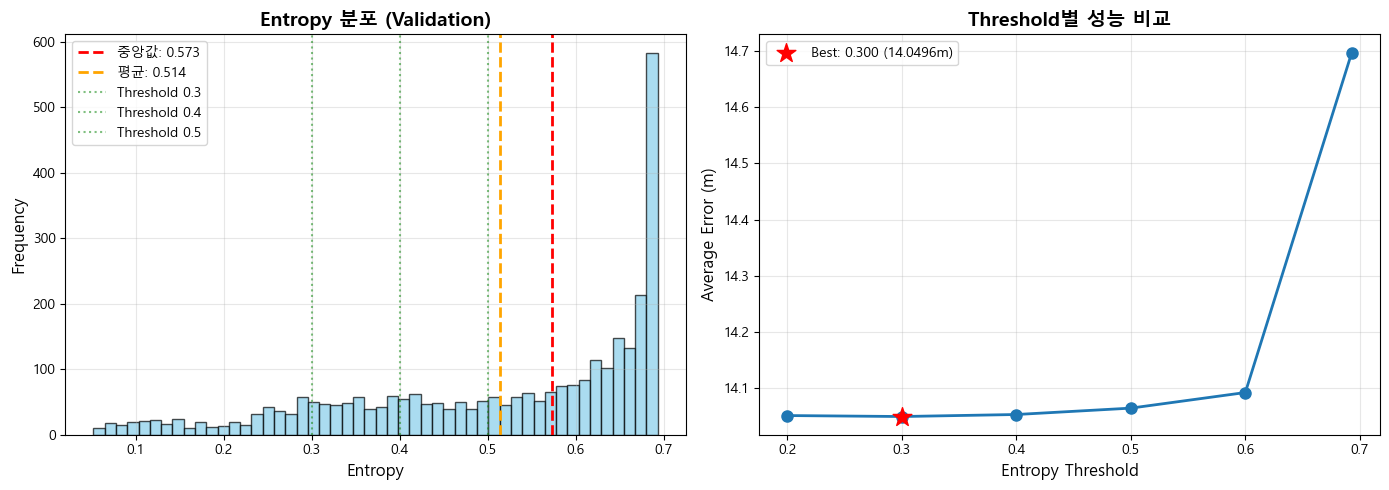


✅ 추천 Threshold: 0.300
  평균 에러: 14.0496m
  Mode 사용: 14.7%
  Mean 사용: 85.3%

💡 이 값을 ENTROPY_THRESHOLD로 사용하세요!


In [57]:
# ======================================================
# 🔍 Entropy 분석 & 최적 Threshold 찾기
# ======================================================
import matplotlib.pyplot as plt

print("="*70)
print("🔍 Entropy 분석 및 최적 Threshold 탐색")
print("="*70)

# Validation 데이터 준비
seed_everything(42)
train_idx, val_idx = train_test_split(range(len(full_dataset)), test_size=0.2, random_state=42)
val_subset_df = train_df[train_df[ID_COL].isin(train_df.groupby(ID_COL).head(1).iloc[val_idx][ID_COL].values)]
val_dataset_test = SoccerDataset(val_subset_df, mode='train', augment_y=False)
val_loader_test = DataLoader(val_dataset_test, batch_size=BATCH_SIZE, shuffle=False, collate_fn=collate_fn)

# 모델 로드 (첫 번째 모델만 사용)
model_for_analysis = ImprovedMDNPredictor(INPUT_DIM, HIDDEN_DIM, LSTM_LAYERS, DROPOUT, 
                                          NUM_GAUSSIANS, BIDIRECTIONAL).to(DEVICE)
model_for_analysis.load_state_dict(torch.load('v12_y_aug_mdn_0.pth'))
model_for_analysis.eval()

# 1️⃣ Entropy 분포 수집
entropies_list = []
pi_list = []
targets_list = []

with torch.no_grad():
    for seqs, targets, mask, lens, _ in val_loader_test:
        seqs, mask, lens = seqs.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
        pi, mu, sigma = model_for_analysis(seqs, mask, lens)
        
        # Entropy 계산
        entropy = -(pi * torch.log(pi + 1e-8)).sum(dim=1)
        entropies_list.extend(entropy.cpu().numpy())
        pi_list.extend(pi.cpu().numpy())
        targets_list.extend(targets.cpu().numpy())

entropies = np.array(entropies_list)
pi_array = np.array(pi_list)
targets_array = np.array(targets_list)

# 2️⃣ Entropy 통계
print(f"\n📊 Entropy 분포 통계 (2 Gaussians, max=0.693)")
print(f"  평균: {entropies.mean():.4f}")
print(f"  중앙값: {np.median(entropies):.4f}")
print(f"  표준편차: {entropies.std():.4f}")
print(f"  최소값: {entropies.min():.4f}")
print(f"  최대값: {entropies.max():.4f}")
print(f"\n  Percentiles:")
for p in [10, 25, 50, 75, 90]:
    print(f"    {p}%: {np.percentile(entropies, p):.4f}")

# 3️⃣ 여러 Threshold로 성능 비교
print(f"\n{'='*70}")
print(f"🧪 Threshold별 성능 비교 (Validation)")
print(f"{'='*70}")

thresholds_to_test = [0.2, 0.3, 0.4, 0.5, 0.6, 0.693]
results_summary = []

for threshold in thresholds_to_test:
    dists = []
    mode_count = 0
    mean_count = 0
    
    with torch.no_grad():
        for seqs, targets, mask, lens, _ in val_loader_test:
            seqs, targets, mask, lens = seqs.to(DEVICE), targets.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
            pi, mu, sigma = model_for_analysis(seqs, mask, lens)
            
            # Smart 전략으로 예측
            pred = mdn_predict_improved(pi, mu, sigma, strategy='smart', entropy_threshold=threshold)
            
            # Entropy 계산 (몇 % mode vs mean 사용했는지 추적)
            entropy = -(pi * torch.log(pi + 1e-8)).sum(dim=1)
            mode_count += (entropy < threshold).sum().item()
            mean_count += (entropy >= threshold).sum().item()
            
            p_real = pred.cpu().numpy() * np.array([105.0, 68.0])
            t_real = targets.cpu().numpy() * np.array([105.0, 68.0])
            dists.extend(np.sqrt(np.sum((p_real - t_real)**2, axis=1)))
    
    avg_dist = np.mean(dists)
    mode_pct = mode_count / (mode_count + mean_count) * 100
    mean_pct = mean_count / (mode_count + mean_count) * 100
    
    results_summary.append({
        'threshold': threshold,
        'avg_error': avg_dist,
        'mode_pct': mode_pct,
        'mean_pct': mean_pct
    })
    
    print(f"Threshold {threshold:.3f}: {avg_dist:.4f}m | Mode: {mode_pct:.1f}% | Mean: {mean_pct:.1f}%")

# 4️⃣ 기본 전략과 비교
print(f"\n{'='*70}")
print(f"📊 기본 전략 비교")
print(f"{'='*70}")

for base_strategy in ['mode', 'mean']:
    dists = []
    with torch.no_grad():
        for seqs, targets, mask, lens, _ in val_loader_test:
            seqs, targets, mask, lens = seqs.to(DEVICE), targets.to(DEVICE), mask.to(DEVICE), lens.to(DEVICE)
            pi, mu, sigma = model_for_analysis(seqs, mask, lens)
            pred = mdn_predict_improved(pi, mu, sigma, strategy=base_strategy)
            p_real = pred.cpu().numpy() * np.array([105.0, 68.0])
            t_real = targets.cpu().numpy() * np.array([105.0, 68.0])
            dists.extend(np.sqrt(np.sum((p_real - t_real)**2, axis=1)))
    
    print(f"{base_strategy.upper()}: {np.mean(dists):.4f}m")

# 5️⃣ 시각화
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Entropy 분포
ax1 = axes[0]
ax1.hist(entropies, bins=50, alpha=0.7, color='skyblue', edgecolor='black')
ax1.axvline(np.median(entropies), color='red', linestyle='--', linewidth=2, label=f'중앙값: {np.median(entropies):.3f}')
ax1.axvline(np.mean(entropies), color='orange', linestyle='--', linewidth=2, label=f'평균: {entropies.mean():.3f}')
for threshold in [0.3, 0.4, 0.5]:
    ax1.axvline(threshold, color='green', linestyle=':', alpha=0.5, label=f'Threshold {threshold}')
ax1.set_xlabel('Entropy', fontsize=12)
ax1.set_ylabel('Frequency', fontsize=12)
ax1.set_title('Entropy 분포 (Validation)', fontsize=14, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Threshold별 성능
ax2 = axes[1]
thresholds = [r['threshold'] for r in results_summary]
errors = [r['avg_error'] for r in results_summary]
ax2.plot(thresholds, errors, marker='o', linewidth=2, markersize=8, color='#1f77b4')
best_idx = np.argmin(errors)
ax2.scatter([thresholds[best_idx]], [errors[best_idx]], color='red', s=200, marker='*', 
            label=f'Best: {thresholds[best_idx]:.3f} ({errors[best_idx]:.4f}m)', zorder=5)
ax2.set_xlabel('Entropy Threshold', fontsize=12)
ax2.set_ylabel('Average Error (m)', fontsize=12)
ax2.set_title('Threshold별 성능 비교', fontsize=14, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('entropy_threshold_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

# 6️⃣ 추천
best_result = results_summary[best_idx]
print(f"\n{'='*70}")
print(f"✅ 추천 Threshold: {best_result['threshold']:.3f}")
print(f"{'='*70}")
print(f"  평균 에러: {best_result['avg_error']:.4f}m")
print(f"  Mode 사용: {best_result['mode_pct']:.1f}%")
print(f"  Mean 사용: {best_result['mean_pct']:.1f}%")
print(f"\n💡 이 값을 ENTROPY_THRESHOLD로 사용하세요!")
print(f"{'='*70}")